Device: cuda


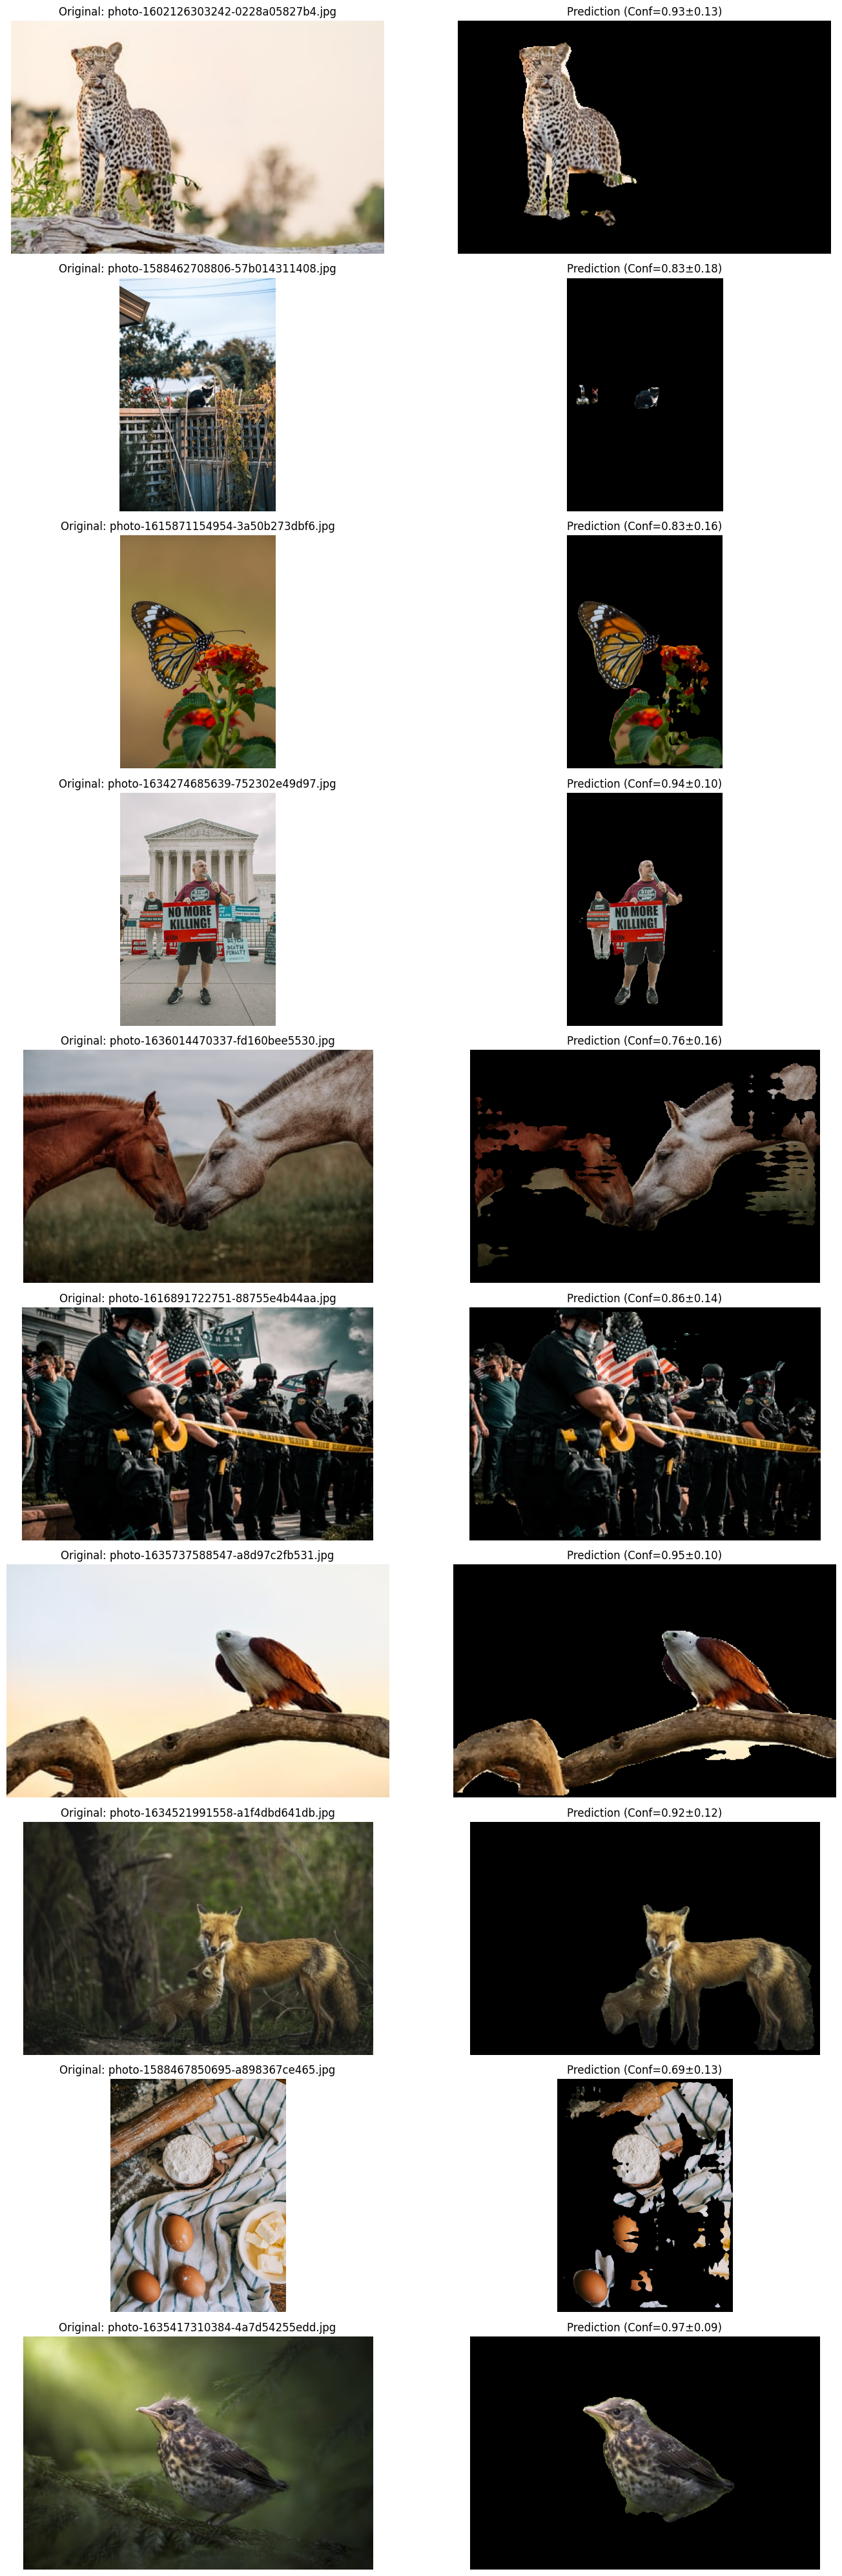

In [10]:
import os, random
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_resnet101
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Paths
MODEL_PATH = r"C:\Users\rahul\Downloads\infosys project\deeplabv3_resnet101_finetuned.pth"
IMAGE_DIR = r"C:\Users\rahul\Downloads\unseendata"

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Load model
model = deeplabv3_resnet101(weights=None, aux_loss=False)
model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)
state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(state_dict, strict=False)
model.to(DEVICE)
model.eval()

# Transform
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def predict_and_overlay(image_path, threshold=0.5):
    orig = Image.open(image_path).convert("RGB")
    inp = transform(orig).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(inp)["out"]
        probs = torch.sigmoid(output)[0, 0].cpu().numpy()

    # Resize mask to original size
    mask = (probs > threshold).astype(np.uint8)
    mask = Image.fromarray(mask*255).resize(orig.size, resample=Image.BILINEAR)
    mask_np = np.array(mask) > 127

    # Apply mask
    orig_np = np.array(orig)
    result = np.zeros_like(orig_np)
    result[mask_np] = orig_np[mask_np]

    # Confidence score
    fg_probs = probs[probs > threshold]
    if fg_probs.size == 0:
        mean_conf, std_conf = 0.0, 0.0
    else:
        mean_conf = fg_probs.mean()
        std_conf = fg_probs.std()

    return orig_np, result, mean_conf, std_conf

# Pick 10 random unseen images
all_images = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
sample_images = random.sample(all_images, min(10, len(all_images)))

# Show results
plt.figure(figsize=(15, 40))
for i, fname in enumerate(sample_images):
    in_path = os.path.join(IMAGE_DIR, fname)
    orig, result, mean_c, std_c = predict_and_overlay(in_path)

    # Original
    plt.subplot(len(sample_images), 2, 2*i+1)
    plt.imshow(orig)
    plt.title(f"Original: {fname}")
    plt.axis("off")

    # Prediction with confidence shown in title (not in terminal)
    plt.subplot(len(sample_images), 2, 2*i+2)
    plt.imshow(result)
    plt.title(f"Prediction (Conf={mean_c:.2f}±{std_c:.2f})")
    plt.axis("off")

plt.tight_layout()
plt.show()
